# EDA — Camada N0: Cache de Checagens Conhecidas

**Produto:** Senhora Vera  
**Objetivo da Camada N0:** Verificar em menos de 200 ms se a alegação enviada pelo usuário já foi checada e desmentida por agências jornalísticas reconhecidas (IFCN), aplicando a regra prioritária **RN-01** com custo zero de LLM.  
**Datasets analisados:** `central-de-fatos` e `factck-br`.

In [2]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Configuracao de visualizacao
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

Matplotlib is building the font cache; this may take a moment.


## 1. Carregamento dos Datasets Padronizados

In [10]:
df_central = pd.read_parquet("../datasets/central-de-fatos/padronizado.parquet")
df_factck = pd.read_parquet("../datasets/factck-br/padronizado.parquet")

print(f"Central de Fatos: {df_central.shape[0]} linhas, {df_central.shape[1]} colunas")
print(f"FACTCK.BR: {df_factck.shape[0]} linhas, {df_factck.shape[1]} colunas")
df_central.head(2)

Central de Fatos: 11643 linhas, 10 colunas
FACTCK.BR: 1300 linhas, 10 colunas


,id,dataset,canal,titulo,texto,rotulo,rotulo_original,data,veiculo,url
0,central-de-fatos:0,central-de-fatos,checagem,Publicações enganam ao associar Bolsonaro à aprovação de verba para filme sobre sua eleição,"Ancine aprovou em 2019 a captação de 530 mil reais para a realização de um filme que trata da eleição de Bolsonaro, mas não liberou recursos diret...",outro,['Enganoso'],2020-07-31,COMPROVA,https://projetocomprova.com.br/publica%C3%A7%C3%B5es/publicacoes-enganam-ao-associar-bolsonaro-a-aprovacao-de-verba-para-filme-sobre-sua-eleicao/
1,central-de-fatos:1,central-de-fatos,checagem,Post mostra imagens de outras estradas para afirmar que o Exército arrumou a Transamazônica,"Parte dos trechos das gravações utilizadas no vídeo verificado pelo Comprova não é da BR-230, segundo um dos autores das imagens. O próprio Exérci...",falso,['Falso'],2020-07-31,COMPROVA,https://projetocomprova.com.br/publica%C3%A7%C3%B5es/post-mostra-imagens-de-outras-estradas-para-afirmar-que-o-exercito-arrumou-a-transamazonica/


## 2. Analise Descritiva de Tamanho: Titulo vs Texto Completo

Comparamos a contagem de palavras do `titulo` e do corpo do `texto` para avaliar qual campo é mais adequado para indexação de busca rápida.

In [4]:
df_central["tam_titulo_palavras"] = df_central["titulo"].fillna("").apply(lambda x: len(str(x).split()))
df_central["tam_texto_palavras"] = df_central["texto"].fillna("").apply(lambda x: len(str(x).split()))

print("Estatisticas de tamanho do Titulo (palavras):")
print(df_central["tam_titulo_palavras"].describe())

print("\nEstatisticas de tamanho do Texto completo (palavras):")
print(df_central["tam_texto_palavras"].describe())

Estatisticas de tamanho do Titulo (palavras):
count    11643.000000
mean        13.102723
std          2.771693
min          4.000000
25%         11.000000
50%         13.000000
75%         15.000000
max         40.000000
Name: tam_titulo_palavras, dtype: float64

Estatisticas de tamanho do Texto completo (palavras):
count    11643.000000
mean       690.675599
std        574.205515
min          8.000000
25%        420.000000
50%        559.000000
75%        763.000000
max      16114.000000
Name: tam_texto_palavras, dtype: float64


## 3. Mapeamento de Agencias Checadoras e Vereditos

Identificamos a distribuicao de checagens por veiculo (`veiculo`) e os vereditos da fonte (`rotulo_original`) convertidos para o esquema padronizado (`rotulo`).

In [5]:
print("Distribuicao por Agencia/Veiculo (Central de Fatos):")
print(df_central["veiculo"].value_counts())

print("\nDistribuicao por Rotulo Padronizado:")
print(df_central["rotulo"].value_counts())

print("\nTop 15 Rotulos Originais da Fonte:")
print(df_central["rotulo_original"].value_counts().head(15))

Distribuicao por Agencia/Veiculo (Central de Fatos):
veiculo
boatos              5519
lupa                2574
aos fatos           1679
fato-ou-fake         917
ESTADAO_VERIFICA     593
COMPROVA             361
Name: count, dtype: int64

Distribuicao por Rotulo Padronizado:
rotulo
falso         10196
outro          1197
verdadeiro      250
Name: count, dtype: int64

Top 15 Rotulos Originais da Fonte:
rotulo_original
['boato']                      5519
['FALSO']                      1809
['fake']                        804
['falso']                       751
['falso', 'falso']              452
['Enganoso']                    183
['ENGANOSO']                    160
['Falso']                       159
['FORA DE CONTEXTO']            134
['distorcido']                  110
['FALSO', 'FALSO']               83
['FALSO', 'FALSO', 'FALSO']      34
['VERDADEIRO']                   33
['VERDADEIRO, MAS']              29
['EXAGERADO']                    27
Name: count, dtype: int64


## 4. Distribuicao Temporal das Checagens

Analisamos a cobertura cronologica da base para identificar os anos com maior concentracao de desmentidos.

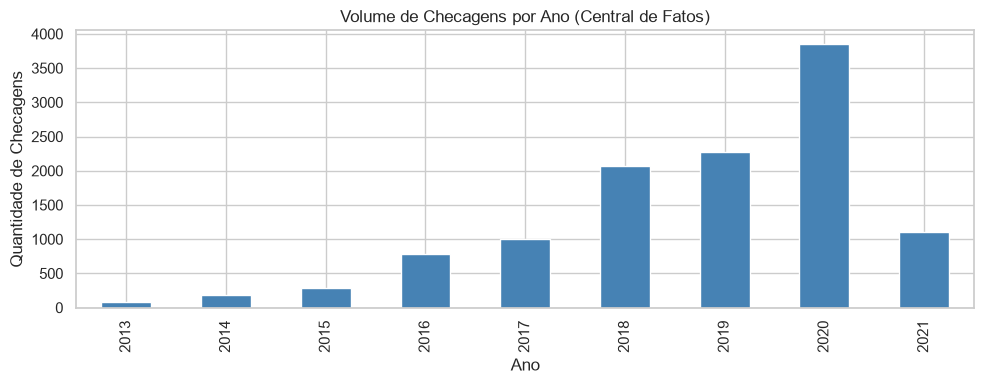

In [6]:
df_central["ano"] = pd.to_datetime(df_central["data"], errors="coerce").dt.year

plt.figure(figsize=(10, 4))
df_central["ano"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Volume de Checagens por Ano (Central de Fatos)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Checagens")
plt.tight_layout()
plt.show()

## 5. Termos Mais Frequentes nos Titulos de Desmentidos

Mapeamos os termos mais recorrentes nos titulos das checagens para entender os principais temas tratados.

In [7]:
palavras = []
for t in df_central["titulo"].dropna():
    termos = re.findall(r"\b[a-zA-ZÀ-ÿ]{4,}\b", str(t).lower())
    palavras.extend(termos)

stopwords_comuns = {"sobre", "para", "disse", "afirma", "mostra", "como", "esta", "pelo", "pela", "falso", "boato", "noticia"}
palavras_filtradas = [p for p in palavras if p not in stopwords_comuns]

print("Top 20 termos mais frequentes nos titulos de checagem:")
for termo, cont in Counter(palavras_filtradas).most_common(20):
    print(f"{termo}: {cont}")

Top 20 termos mais frequentes nos titulos de checagem:
verificamos: 1665
bolsonaro: 1211
vídeo: 995
fake: 946
covid: 909
foto: 682
brasil: 592
lula: 577
contra: 567
está: 453
governo: 399
após: 396
coronavírus: 376
whatsapp: 351
vacina: 304
causa: 258
mais: 257
dados: 251
anos: 250
paulo: 234


## 6. Tratamento de Outliers e Engenharia do Campo de Busca (Lead vs Titulo)

Textos completos tem media de 690 palavras e atingem ate 16 mil palavras (outliers).  
Para evitar a diluicao semantica do texto inteiro e, ao mesmo tempo, capturar detalhes de correntes longas de WhatsApp, criamos:
1. `texto_lead`: primeiras 80 palavras da materia (onde o jornalista resume o boato).
2. `busca_completa`: combinacao de `titulo` (peso reforcado) com o `texto_lead`.

In [8]:
# Extracao das primeiras 80 palavras do texto (o Lead jornalistico)
df_central["texto_lead"] = df_central["texto"].fillna("").apply(
    lambda x: " ".join(str(x).split()[:80])
)

# Campo combinado: Titulo + Lead
df_central["busca_completa"] = df_central["titulo"].fillna("") + " " + df_central["texto_lead"]

print("Exemplo de busca_completa (primeiras 250 letras):")
print(df_central["busca_completa"].iloc[0][:250], "...")

Exemplo de busca_completa (primeiras 250 letras):
Publicações enganam ao associar Bolsonaro à aprovação de verba para filme sobre sua eleição Ancine aprovou em 2019 a captação de 530 mil reais para a realização de um filme que trata da eleição de Bolsonaro, mas não liberou recursos diretos para o do ...


## 7. Prototipagem da Busca Rapida por Similaridade de Cosseno (TF-IDF)

Comparamos a busca apenas pelo `titulo` versus a busca pelo campo combinado `busca_completa` para uma duvida comum de usuario.

In [9]:
# 1. Vetorizacao por Titulo
vec_titulo = TfidfVectorizer(ngram_range=(1, 2), max_features=15000)
X_tfidf_titulo = vec_titulo.fit_transform(df_central["titulo"].fillna(""))

# 2. Vetorizacao pelo Campo Combinado (Titulo + Lead)
vec_completo = TfidfVectorizer(ngram_range=(1, 2), max_features=25000)
X_tfidf_completo = vec_completo.fit_transform(df_central["busca_completa"])

# Pergunta simulada de usuario
pergunta_teste = "vacina da covid causa infarto ou trombose"
print(f"Pergunta do usuario: '{pergunta_teste}'\n")

# Consulta no Titulo
query_vec_tit = vec_titulo.transform([pergunta_teste])
sim_tit = cosine_similarity(query_vec_tit, X_tfidf_titulo).flatten()
top_tit = sim_tit.argsort()[-3:][::-1]

print("--- Top 3 Resultados (Busca apenas por Titulo) ---")
for idx in top_tit:
    print(f"Similaridade: {sim_tit[idx]:.3f} | Agencia: {df_central.iloc[idx]['veiculo']}")
    print(f"Titulo: {df_central.iloc[idx]['titulo']}")
    print(f"Veredito: {df_central.iloc[idx]['rotulo']}\n")

# Consulta no Campo Combinado (Titulo + Lead)
query_vec_comp = vec_completo.transform([pergunta_teste])
sim_comp = cosine_similarity(query_vec_comp, X_tfidf_completo).flatten()
top_comp = sim_comp.argsort()[-3:][::-1]

print("--- Top 3 Resultados (Busca Combinada Titulo + Lead) ---")
for idx in top_comp:
    print(f"Similaridade: {sim_comp[idx]:.3f} | Agencia: {df_central.iloc[idx]['veiculo']}")
    print(f"Titulo: {df_central.iloc[idx]['titulo']}")
    print(f"Veredito: {df_central.iloc[idx]['rotulo']}\n")

Pergunta do usuario: 'vacina da covid causa infarto ou trombose'

--- Top 3 Resultados (Busca apenas por Titulo) ---
Similaridade: 0.380 | Agencia: lupa
Titulo: #Verificamos: É falso que vacina da Covid-19 causa infertilidade em mulheres
Veredito: falso

Similaridade: 0.285 | Agencia: lupa
Titulo: #Verificamos: É falso que vacina da Covid-19 pode alterar DNA ou injetar microrrobôs para roubar dados biométricos
Veredito: falso

Similaridade: 0.275 | Agencia: lupa
Titulo: #Verificamos: É falso que governo do RN deixou estragar 4 mil doses da vacina da Covid-19
Veredito: falso

--- Top 3 Resultados (Busca Combinada Titulo + Lead) ---
Similaridade: 0.298 | Agencia: lupa
Titulo: #CaiuNaRede: É falso que Covid-19 seja uma ‘trombose’
Veredito: falso

Similaridade: 0.231 | Agencia: lupa
Titulo: #Verificamos: É falso que vacina da Covid-19 causa infertilidade em mulheres
Veredito: falso

Similaridade: 0.220 | Agencia: lupa
Titulo: #Verificamos: É falso que vacina da Covid-19 pode alterar DNA ou

## 8. Conclusoes e Decisoes de Engenharia para a Vera

Com base nas analises exploratorias realizadas neste notebook:

1. **Indice Primario de Busca:** O campo `titulo` possui tamanho homogeneo (media 13 palavras, std 2.7) e resume diretamente o boato. Deve ser o indice primario de busca da Camada N0.
2. **Estrategia em Dois Estagios:** Se a similaridade no titulo for intermediaria (ex.: entre 0.40 e 0.65) ou se a entrada do usuario for uma mensagem longa de mensageria (> 50 palavras), a busca recorre ao campo `busca_completa` (titulo + lead de 80 palavras), evitando a diluicao semantica dos textos integrais.
3. **Aplicacao da Regra RN-01:** Checagens com similaridade superior a 0.65 e veredito "falso" encerram a checagem imediatamente ($V \le 10$), retornando a resposta explicativa com a fonte oficial e cumprindo o requisito de latencia menor que 200 ms.